In [1]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")
DATA_DIR = PROJECT_ROOT / "data"

def read_json(file_path: Path | str) -> dict | list:
    data = None
    with open(file_path, "r") as f:
        data = json.load(f)
    return data

def read_jsonl(file_path: Path | str) -> list:
    res = []
    with open(file_path, "r") as f:
        for line in f:
            res.append(json.loads(line))
    return res

def write_json(data: dict | list, file_path: Path | str) -> None:
    with open(file_path, "w") as f:
        json.dump(data, f, indent=4)
        print(f"wrote to {file_path}")
        

Project root: /home/v-homatthew/ctx_editor


In [2]:
# math
# outputs/2026-03-06/04-56-49
# outputs/2026-03-06/05-11-40
# outputs/2026-03-06/05-57-29

# code
# outputs/2026-03-06/06-11-33
# outputs/2026-03-06/07-31-16
# outputs/2026-03-06/08-26-32

latest_output_dirs = {
    "math": [
        "outputs/2026-03-06/04-56-49",
        "outputs/2026-03-06/05-11-40",
        "outputs/2026-03-06/05-57-29",
    ],
    "code": [
        "outputs/2026-03-06/06-11-33",
        "outputs/2026-03-06/07-31-16",
        "outputs/2026-03-06/08-26-32",
    ],
}

In [4]:
!ls {PROJECT_ROOT / latest_output_dirs["math"][0]}

config.yaml		     metrics.json	 summary.txt
content_filter_errors.jsonl  results.json	 traces
experiment.log		     run_experiment.log  verbose.log


In [5]:
dummy_res = read_json(PROJECT_ROOT / latest_output_dirs["math"][0] / "results.json")

In [11]:
dummy_res[0].keys()

dict_keys(['sample_id', 'task_name', 'is_correct', 'score', 'num_turns', 'total_cost_usd', 'extracted_answer', 'metadata', 'timestamp', 'usage_stats'])

In [12]:
def get_min_results(output_dir: Path) -> dict[str, bool]:
    # get minimal results representation: {question_id: is_correct}
    results = read_json(output_dir / "results.json")
    min_results = {}
    for res_entry in results:
        sample_id = res_entry["sample_id"]
        is_correct = res_entry["is_correct"]
        score = res_entry["score"]
        # if both of is_correct and score are non-None, then they should be consistent
        final_correct = None
        if is_correct is not None and score is not None:
            if not (is_correct == (score == 1.0)):
                print(f"Warning: inconsistent is_correct and score for sample_id {sample_id}")
            final_correct = is_correct
        else:
            if is_correct is not None:
                final_correct = is_correct
            elif score is not None:
                final_correct = (score == 1.0)
        min_results[sample_id] = final_correct
    return min_results

In [14]:
min_res_dict = {
    "math": [get_min_results(PROJECT_ROOT / output_dir) for output_dir in latest_output_dirs["math"]],
    "code": [get_min_results(PROJECT_ROOT / output_dir) for output_dir in latest_output_dirs["code"]],
}


In [15]:
# next is to do analysis over 3 runs of each kind
# here's what I'm interested in
# are the set of incorrect questions consistent?


# analysis 1: error set overlap
def get_err_set(min_res: dict[str, bool]) -> set[str]:
    return set(sample_id for sample_id, is_correct in min_res.items() if not is_correct)

err_sets = {
    "math": [get_err_set(min_res) for min_res in min_res_dict["math"]],
    "code": [get_err_set(min_res) for min_res in min_res_dict["code"]],
}
# print each set size
for task in ["math", "code"]:
    for i, err_set in enumerate(err_sets[task]):
        print(f"{task} run {i} error set size: {len(err_set)}")

# print pairwise overlaps
for task in ["math", "code"]:
    print(f"{task} pairwise overlaps:")
    for i in range(len(err_sets[task])):
        for j in range(i + 1, len(err_sets[task])):
            overlap = err_sets[task][i].intersection(err_sets[task][j])
            print(f"run {i} and run {j} overlap: {len(overlap)}")
    
# print three-way overlaps
for task in ["math", "code"]:
    overlap = err_sets[task][0].intersection(err_sets[task][1]).intersection(err_sets[task][2])
    print(f"{task} three-way overlap: {len(overlap)}")


math run 0 error set size: 19
math run 1 error set size: 16
math run 2 error set size: 12
code run 0 error set size: 25
code run 1 error set size: 26
code run 2 error set size: 29
math pairwise overlaps:
run 0 and run 1 overlap: 6
run 0 and run 2 overlap: 6
run 1 and run 2 overlap: 4
code pairwise overlaps:
run 0 and run 1 overlap: 16
run 0 and run 2 overlap: 18
run 1 and run 2 overlap: 19
math three-way overlap: 2
code three-way overlap: 16


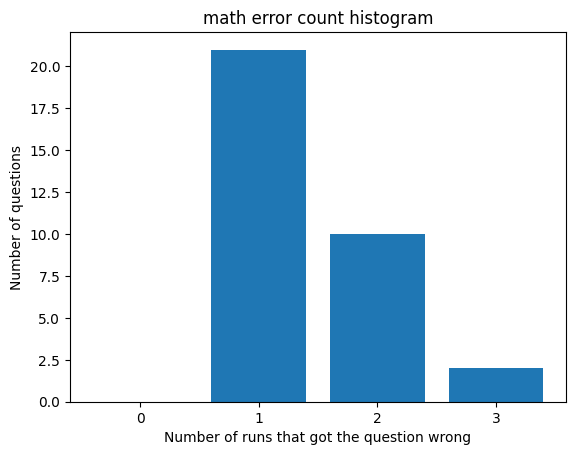

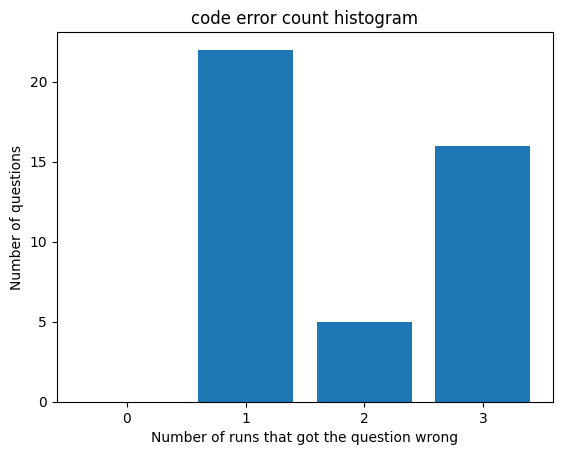

In [ ]:
# analysis 2: for each question, count how many runs got it wrong
# goal get dict[str, int] mapping question_id to number of runs that got it wrong
err_count = {
    "math": defaultdict(int),
    "code": defaultdict(int),
}
for task in ["math", "code"]:
    for min_res in min_res_dict[task]:
        for sample_id, is_correct in min_res.items():
            if not is_correct:
                err_count[task][sample_id] += 1

# print histogram of err_count
for task in ["math", "code"]:
    count_values = list(err_count[task].values())
    plt.hist(count_values, bins=np.arange(-0.5, 4.5, 1), rwidth=0.8)
    plt.xlabel("Number of runs that got the question wrong")
    plt.ylabel("Number of questions")
    plt.title(f"{task} error count histogram")
    plt.xticks([0, 1, 2, 3])
    plt.show()
